<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/rock_flow_pore_to_field_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rock and reservoir flow: from pore space to field development with NeqSim

**Audience.** Reservoir, production, process, and field-development engineers and students
who want an executable bridge between digital rock, SCAL, continuum reservoir simulation,
wells, and facilities.

**Learning outcomes**

- distinguish porosity, connected porosity, absolute permeability, relative permeability,
  capillary pressure, mobility, transmissibility, and well productivity;
- create a synthetic three-dimensional rock image and simulate drainage with PoreSpy;
- extract a pore network and calculate absolute permeability with OpenPNM;
- obtain pressure-dependent oil and water properties from current NeqSim Java `master`;
- construct Corey relative-permeability and Brooks-Corey capillary-pressure tables;
- generate a heterogeneous permeability field with GSTools and run a transparent two-phase
  finite-volume waterflood;
- screen water breakthrough, injection pressure, recovery, well count, and facility loads;
- flash selected produced-fluid states in a NeqSim three-phase separator; and
- export auditable rock and SCAL handoffs for a later OPM Flow study.

The example is synthetic, deterministic, and public. It is a teaching and concept-screening
model, not a history-matched reservoir forecast or a substitute for laboratory SCAL, a
geomodel, a compositional reservoir simulator, or flow-assurance design.


## Engineering question and calculation chain

A development team has a volatile-oil discovery and only early rock and fluid information.
What can be learned about injectivity, waterflood sweep, breakthrough, recovery, well count,
and receiving-facility loads before a decision-grade sector model exists?

The notebook preserves the scale transitions explicitly:

1. **Pore image:** connected void space and capillary invasion.
2. **Pore network/core:** single-phase permeability and SCAL concepts.
3. **Grid block:** upscaled porosity, permeability, and saturation functions.
4. **Reservoir pattern:** pressure solution and explicit saturation transport.
5. **Well and facility:** pressure constraints, produced-water load, and phase separation.

Information moves upward in scale; the pore-scale geometry is not silently treated as a
field-scale geological realization. Every pressure is absolute. Permeability is reported in
millidarcies (mD), viscosity in centipoise (cP), reservoir volume in m³ at reservoir
conditions, and standard gas volume at NeqSim's standard state.


## Selected Python toolchain

| Library | Role in this notebook | Decision-grade extension |
|---|---|---|
| [PoreSpy](https://porespy.org/) | Synthetic voxel rock, connectivity, capillary transform, and drainage | Apply to segmented micro-CT with image-resolution and representativity studies |
| [OpenPNM](https://openpnm.org/) | Extracted pore network and Stokes-flow permeability | Calibrate network geometry against measured permeability and capillary data |
| [GSTools](https://gstools.readthedocs.io/) | Reproducible anisotropic spatial random field | Fit variograms and condition realizations to wells and seismic attributes |
| [SciPy](https://docs.scipy.org/doc/scipy/) | Sparse finite-volume pressure solve | Replace the teaching solver with a fully implicit simulator |
| [OPM Flow](https://opm-project.org/) | Downstream industrial black-oil simulation target | Run full grids, schedules, controls, restart states, and uncertainty ensembles |
| [NeqSim](https://github.com/equinor/neqsim) | EOS-based fluid properties and a composable surface separator | Tune PVT, characterize heavy ends, and couple wells/SURF/process constraints |

PoreSpy resolves image-based displacement, OpenPNM resolves a reduced pore network, GSTools
handles spatial uncertainty, and NeqSim supplies thermodynamic and transport properties.
None of these tools alone replaces a complete reservoir-development workflow.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys


os.environ.setdefault("MPLCONFIGDIR", "/tmp/rock-flow-matplotlib")

REQUIRED_PACKAGES = {
    "openpnm": "3.6.4",
    "porespy": "3.0.4",
    "gstools": "1.7.0",
}
SUPPORT_PACKAGES = {
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "requests": "requests",
    "scipy": "scipy",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


pinned_missing = [
    f"{name}=={required}"
    for name, required in REQUIRED_PACKAGES.items()
    if installed_version(name) != required
]
support_missing = [
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
install_specs = pinned_missing + support_missing
if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
        timeout=900,
    )

print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
import hashlib
import json
import math
import platform
import shutil
import warnings

import psutil

try:
    psutil.Process()
except psutil.NoSuchProcess:
    # Some container validators expose a host PID but a nested /proc view.
    original_process = psutil.Process
    psutil.Process = lambda pid=None: original_process(
        1 if pid is None else pid
    )

import gstools as gs
import jpype
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import openpnm as op
import pandas as pd
import porespy as ps
import requests
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

OUTPUT_DIRECTORY = Path("rock_flow_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()

package_versions = pd.DataFrame(
    {
        "package": [
            "Python",
            "OpenPNM",
            "PoreSpy",
            "GSTools",
            "NumPy",
            "SciPy",
        ],
        "version": [
            platform.python_version(),
            version("openpnm"),
            version("porespy"),
            version("gstools"),
            version("numpy"),
            version("scipy"),
        ],
    }
)
display(package_versions)


,package,version
0,Python,3.12.13
1,OpenPNM,3.6.4
2,PoreSpy,3.0.4
3,GSTools,1.7.0
4,NumPy,2.4.6
5,SciPy,1.18.0


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(
            f"Command failed ({result.returncode}): {command}\n{tail}"
        )
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source,
            timeout=600,
        )
        run_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=neqsim_source,
        )
    run_command(
        [
            "./mvnw",
            "-q",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=neqsim_source,
        timeout=1500,
    )
    built_jars = sorted(
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    shaded_jars = [path for path in built_jars if "shaded" in path.name]
    neqsim_jar = shaded_jars[-1] if shaded_jars else built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(
    ["git", "rev-parse", "HEAD"],
    cwd=neqsim_source,
)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    jpype.startJVM()

JClass = jpype.JClass
HostFacility = JClass(
    "neqsim.process.fielddevelopment.tieback.HostFacility"
)
class_source = str(
    HostFacility.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance = pd.DataFrame(
    {
        "item": [
            "NeqSim source ref",
            "NeqSim commit",
            "JAR SHA-256",
            "Java class source",
        ],
        "resolved value": [
            NEQSIM_SOURCE_REF,
            neqsim_commit,
            neqsim_jar_sha256,
            class_source,
        ],
    }
)
display(provenance)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,df68ad7295b9dae6a324d941761a303d9f301fb5
2,JAR SHA-256,091465d928d7935a7197482b3b5aa41fecdd3535af7562...
3,Java class source,file:/workspace/scratch/7d6c3e2e9160/neqsim-ja...


In [4]:
SystemSrkCPAstatoil = JClass(
    "neqsim.thermo.system.SystemSrkCPAstatoil"
)
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

RESERVOIR_TEMPERATURE_C = 90.0
INITIAL_PRESSURE_BARA = 250.0
PRODUCER_BHP_BARA = 150.0
WATER_INJECTION_PRESSURE_LIMIT_BARA = 260.0
STANDARD_SECONDS_PER_DAY = 86_400.0
M2_PER_MD = 9.869233e-16

study_basis = pd.DataFrame(
    {
        "quantity": [
            "reservoir temperature",
            "initial pressure",
            "producer BHP",
            "water-injection pressure limit",
            "forecast length",
            "random seed",
        ],
        "value": [
            RESERVOIR_TEMPERATURE_C,
            INITIAL_PRESSURE_BARA,
            PRODUCER_BHP_BARA,
            WATER_INJECTION_PRESSURE_LIMIT_BARA,
            8.0,
            20_260_806,
        ],
        "unit": ["°C", "bara", "bara", "bara", "year", "-"],
    }
)
display(study_basis)


,quantity,value,unit
0,reservoir temperature,90,°C
1,initial pressure,250,bara
2,producer BHP,150,bara
3,water-injection pressure limit,260,bara
4,forecast length,8,year
5,random seed,2.026e+07,-


## 1. NeqSim reservoir-fluid properties

Darcy mobility depends on viscosity, while pressure gradients and surface mass loads depend
on density. These are not arbitrary tuning constants here: a characterized synthetic live
oil is flashed with NeqSim's Statoil CPA implementation and classic CPA mixing rule.

For phase $\alpha$, mobility is

$$\lambda_\alpha=\frac{k_{r\alpha}}{\mu_\alpha}$$

and the phase Darcy velocity is

$$\mathbf{u}_\alpha=-\mathbf{K}\lambda_\alpha\left(\nabla p_\alpha-\rho_\alpha\mathbf{g}\right)$$

Here $\mathbf{K}$ is the absolute-permeability tensor in m², $k_{r\alpha}$ is relative
permeability, $\mu_\alpha$ is viscosity in Pa s, $p_\alpha$ is pressure in Pa, and
$\rho_\alpha$ is density in kg/m³. Gravity is omitted from the horizontal teaching model but
retained in the governing equation to show the full handoff.


In [5]:
HYDROCARBON_COMPONENTS = [
    ("methane", 25.0),
    ("ethane", 5.0),
    ("propane", 5.0),
    ("n-butane", 4.0),
    ("n-pentane", 4.0),
    ("n-hexane", 6.0),
    ("n-heptane", 8.0),
    ("n-octane", 8.0),
]


def build_live_oil(temperature_c, pressure_bara, water_moles=0.0):
    fluid = SystemSrkCPAstatoil(
        273.15 + float(temperature_c),
        float(pressure_bara),
    )
    for component_name, amount in HYDROCARBON_COMPONENTS:
        fluid.addComponent(component_name, amount)
    fluid.addTBPfraction("C10", 15.0, 0.142, 0.78)
    fluid.addTBPfraction("C20", 20.0, 0.282, 0.88)
    if water_moles > 0.0:
        fluid.addComponent("water", float(water_moles))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    return fluid


def build_reservoir_water(temperature_c, pressure_bara):
    water = SystemSrkCPAstatoil(
        273.15 + float(temperature_c),
        float(pressure_bara),
    )
    water.addComponent("water", 100.0)
    water.setMixingRule(10)
    water.setMultiPhaseCheck(True)
    ThermodynamicOperations(water).TPflash()
    water.initProperties()
    return water


pressure_grid_bara = np.asarray(
    [20.0, 40.0, 60.0, 80.0, 100.0, 150.0, 200.0, 250.0, 300.0]
)
pvt_rows = []
for pressure_bara in pressure_grid_bara:
    state = build_live_oil(
        RESERVOIR_TEMPERATURE_C,
        pressure_bara,
    )
    oil_phase = state.getPhase("oil")
    gas_fraction = (
        state.getPhase("gas").getBeta()
        if state.hasPhaseType("gas")
        else 0.0
    )
    pvt_rows.append(
        {
            "pressure_bara": pressure_bara,
            "oil_density_kg_m3": oil_phase.getDensity("kg/m3"),
            "oil_viscosity_cP": oil_phase.getViscosity("cP"),
            "gas_molar_fraction": gas_fraction,
        }
    )

pvt_table = pd.DataFrame(pvt_rows)
reservoir_oil = build_live_oil(
    RESERVOIR_TEMPERATURE_C,
    INITIAL_PRESSURE_BARA,
)
reservoir_water = build_reservoir_water(
    RESERVOIR_TEMPERATURE_C,
    INITIAL_PRESSURE_BARA,
)
oil_density_kg_m3 = float(
    reservoir_oil.getPhase("oil").getDensity("kg/m3")
)
oil_viscosity_cp = float(
    reservoir_oil.getPhase("oil").getViscosity("cP")
)
water_density_kg_m3 = float(
    reservoir_water.getPhase("aqueous").getDensity("kg/m3")
)
water_viscosity_cp = float(
    reservoir_water.getPhase("aqueous").getViscosity("cP")
)
display(pvt_table)


,pressure_bara,oil_density_kg_m3,oil_viscosity_cP,gas_molar_fraction
0,20,735,0.4863,0.279
1,40,719.8,0.4369,0.195
2,60,707,0.3884,0.1205
3,80,694.9,0.3493,0.04595
4,100,689.5,0.3336,0
5,150,698.8,0.362,0
6,200,707,0.3884,0
7,250,714.2,0.4133,0
8,300,720.6,0.4368,0


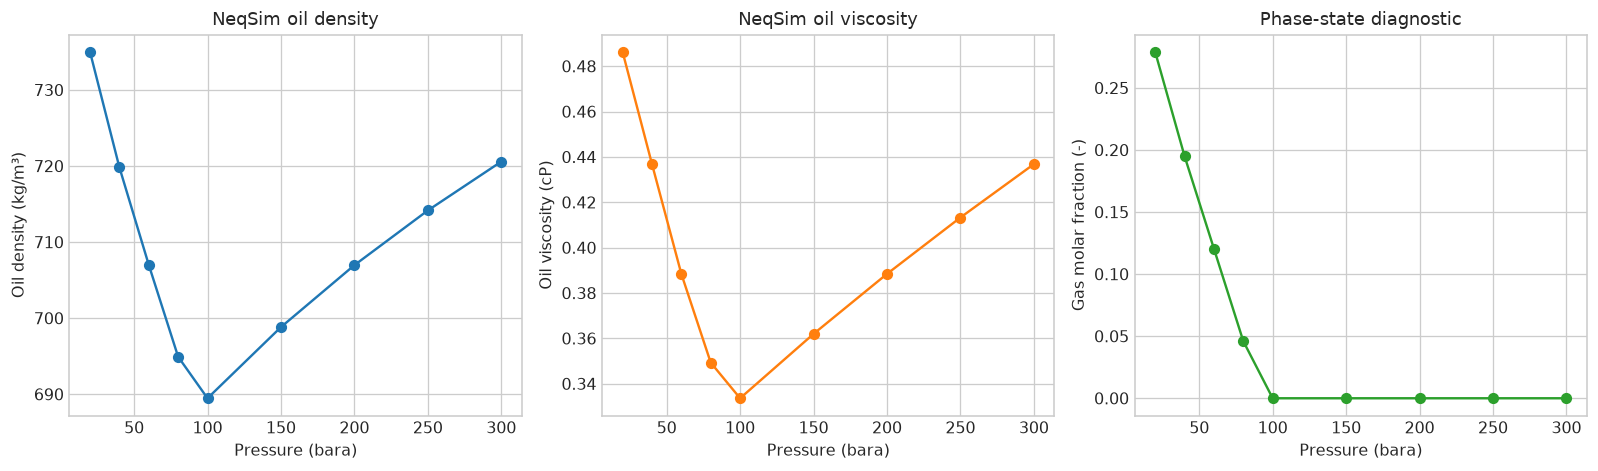

,phase,density_kg_m3,viscosity_cP
0,oil,714.2,0.4133
1,water,984.2,0.323


In [6]:
pvt_figure, pvt_axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
pvt_axes[0].plot(
    pvt_table["pressure_bara"],
    pvt_table["oil_density_kg_m3"],
    marker="o",
)
pvt_axes[0].set(
    xlabel="Pressure (bara)",
    ylabel="Oil density (kg/m³)",
    title="NeqSim oil density",
)
pvt_axes[1].plot(
    pvt_table["pressure_bara"],
    pvt_table["oil_viscosity_cP"],
    marker="o",
    color="tab:orange",
)
pvt_axes[1].set(
    xlabel="Pressure (bara)",
    ylabel="Oil viscosity (cP)",
    title="NeqSim oil viscosity",
)
pvt_axes[2].plot(
    pvt_table["pressure_bara"],
    pvt_table["gas_molar_fraction"],
    marker="o",
    color="tab:green",
)
pvt_axes[2].set(
    xlabel="Pressure (bara)",
    ylabel="Gas molar fraction (-)",
    title="Phase-state diagnostic",
)
pvt_figure.tight_layout()
plt.show()

fluid_summary = pd.DataFrame(
    {
        "phase": ["oil", "water"],
        "density_kg_m3": [oil_density_kg_m3, water_density_kg_m3],
        "viscosity_cP": [oil_viscosity_cp, water_viscosity_cp],
    }
)
display(fluid_summary)


## 2. Digital rock: porosity and connected pore volume

Porosity is a volume fraction, but only connected pore space can transmit fluid across the
sample. The three-dimensional synthetic image below has a target porosity of 25%. PoreSpy
trims void clusters that cannot be reached from the inlet face. The image is deliberately
small enough for Colab; it is not a representative elementary volume for a real formation.

$$\phi=\frac{V_{pore}}{V_{bulk}}$$

$$\phi_c=\frac{V_{pore,connected}}{V_{bulk}}$$

A real digital-rock workflow would test segmentation, voxel size, sample orientation,
mineralogy, wettability, and convergence with sample volume.


,metric,value,unit
0,total porosity,0.25,-
1,inlet-connected porosity,0.2442,-
2,connected fraction of pore volume,0.9766,-
3,connected outlet voxels,"1,029",voxel


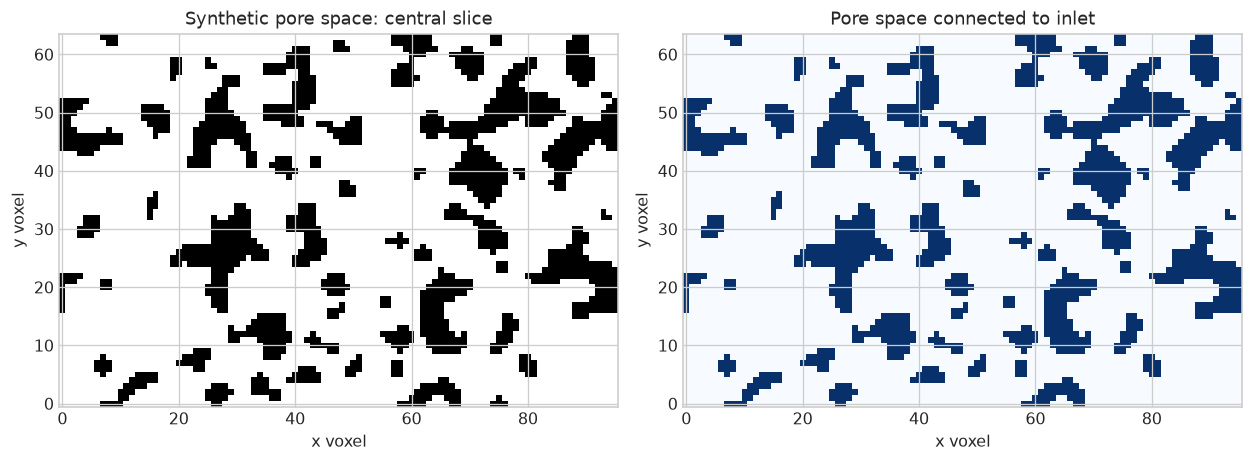

In [7]:
ROCK_SHAPE = (96, 64, 64)
VOXEL_SIZE_M = 4.0e-6
TARGET_POROSITY = 0.25
ROCK_SEED = 20_260_806

pore_image = ps.generators.blobs(
    shape=ROCK_SHAPE,
    porosity=TARGET_POROSITY,
    blobiness=1.2,
    seed=ROCK_SEED,
)
inlet_face = ps.generators.faces(pore_image.shape, inlet=0)
outlet_face = ps.generators.faces(pore_image.shape, outlet=0)
connected_image = ps.filters.trim_disconnected_voxels(
    im=pore_image,
    inlets=inlet_face & pore_image,
)
inlet_voxels = inlet_face & connected_image
outlet_voxels = outlet_face & connected_image

porosity_table = pd.DataFrame(
    {
        "metric": [
            "total porosity",
            "inlet-connected porosity",
            "connected fraction of pore volume",
            "connected outlet voxels",
        ],
        "value": [
            pore_image.mean(),
            connected_image.mean(),
            connected_image.sum() / pore_image.sum(),
            outlet_voxels.sum(),
        ],
        "unit": ["-", "-", "-", "voxel"],
    }
)
display(porosity_table)

slice_index = ROCK_SHAPE[2] // 2
image_figure, image_axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
image_axes[0].imshow(
    pore_image[:, :, slice_index].T,
    origin="lower",
    cmap="gray_r",
    aspect="equal",
)
image_axes[0].set_title("Synthetic pore space: central slice")
image_axes[1].imshow(
    connected_image[:, :, slice_index].T,
    origin="lower",
    cmap="Blues",
    aspect="equal",
)
image_axes[1].set_title("Pore space connected to inlet")
for axis in image_axes:
    axis.set_xlabel("x voxel")
    axis.set_ylabel("y voxel")
image_figure.tight_layout()
plt.show()


## 3. Capillary entry and image-based drainage

For a cylindrical throat, the Young-Laplace screening relation is

$$p_c=-\frac{2\sigma\cos\theta}{r}$$

where $p_c$ is capillary pressure in Pa, $\sigma$ is interfacial tension in N/m, $\theta$ is
the contact angle measured through the wetting phase, and $r$ is throat radius in m. A
non-wetting oil phase is injected from the left while the wetting phase may escape at the
right. Trapping and image connectivity mean the final invaded saturation need not be one.

Capillary pressure affects vertical equilibrium, transition zones, initialization, and
displacement. The later horizontal field model omits capillary flux so that its numerical
assumptions remain transparent; the calculated curve is exported for OPM Flow instead.


In [8]:
INTERFACIAL_TENSION_N_M = 0.030
CONTACT_ANGLE_DEG = 150.0

capillary_transform = ps.filters.capillary_transform(
    im=connected_image,
    sigma=INTERFACIAL_TENSION_N_M,
    theta=CONTACT_ANGLE_DEG,
    voxel_size=VOXEL_SIZE_M,
)
invasion = ps.simulations.injection(
    im=connected_image,
    pc=capillary_transform,
    inlets=inlet_voxels,
    outlets=outlet_voxels,
    maxiter=200_000,
    method="qbip",
)
invasion_curve_raw = ps.metrics.pc_map_to_pc_curve(
    pc=invasion.im_pc,
    im=connected_image,
    seq=invasion.im_seq,
)
curve_mask = np.isfinite(invasion_curve_raw.pc)
invasion_curve = pd.DataFrame(
    {
        "pc_kpa": invasion_curve_raw.pc[curve_mask] / 1000.0,
        "nonwetting_saturation": invasion_curve_raw.snwp[curve_mask],
    }
)
invasion_curve = (
    invasion_curve.groupby("pc_kpa", as_index=False)
    .max()
    .sort_values("pc_kpa")
)
invaded_mask = (invasion.im_seq > 0) & connected_image

invasion_summary = pd.DataFrame(
    {
        "metric": [
            "minimum invaded capillary pressure",
            "maximum finite capillary pressure",
            "final non-wetting saturation",
            "uninvaded connected pore fraction",
        ],
        "value": [
            invasion_curve["pc_kpa"].min(),
            invasion_curve["pc_kpa"].max(),
            invasion_curve["nonwetting_saturation"].max(),
            1.0 - invaded_mask.sum() / connected_image.sum(),
        ],
        "unit": ["kPa", "kPa", "-", "-"],
    }
)
display(invasion_summary)


,metric,value,unit
0,minimum invaded capillary pressure,3.248,kPa
1,maximum finite capillary pressure,12.99,kPa
2,final non-wetting saturation,0.4027,-
3,uninvaded connected pore fraction,0.5973,-


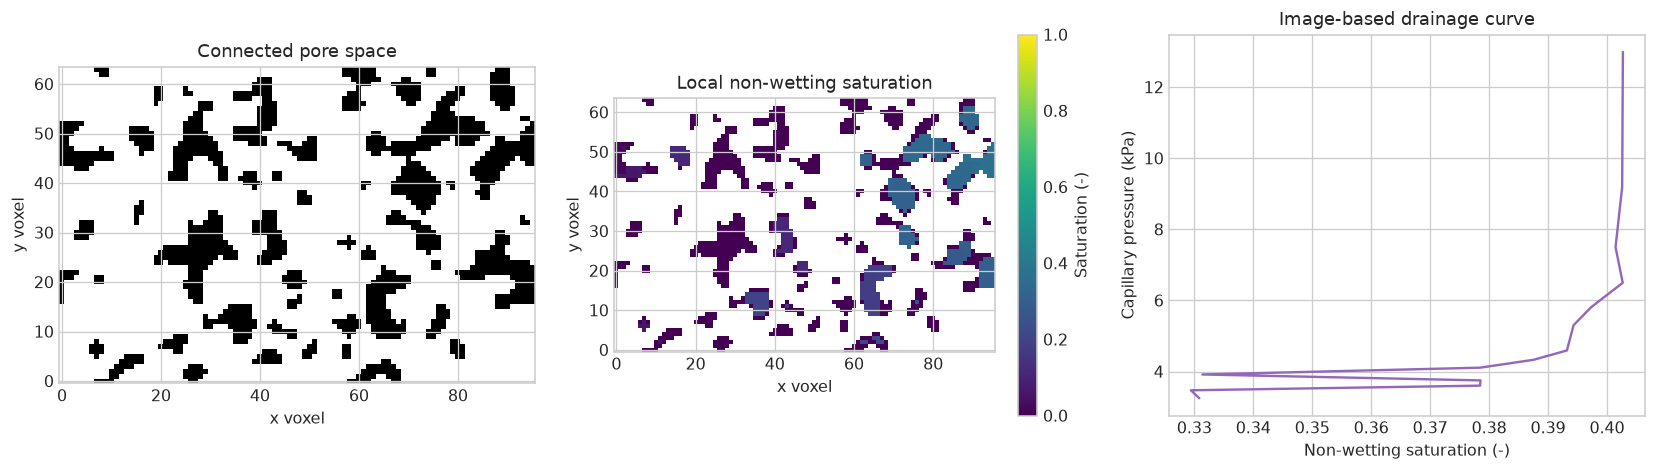

In [9]:
invasion_figure, invasion_axes = plt.subplots(
    1,
    3,
    figsize=(14.5, 4.2),
)
invasion_axes[0].imshow(
    connected_image[:, :, slice_index].T,
    origin="lower",
    cmap="gray_r",
)
invasion_axes[0].set_title("Connected pore space")
invaded_slice = np.where(
    connected_image[:, :, slice_index],
    invasion.im_snwp[:, :, slice_index],
    np.nan,
)
invasion_image = invasion_axes[1].imshow(
    invaded_slice.T,
    origin="lower",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
invasion_axes[1].set_title("Local non-wetting saturation")
invasion_figure.colorbar(
    invasion_image,
    ax=invasion_axes[1],
    label="Saturation (-)",
)
invasion_axes[2].plot(
    invasion_curve["nonwetting_saturation"],
    invasion_curve["pc_kpa"],
    color="tab:purple",
)
invasion_axes[2].set(
    xlabel="Non-wetting saturation (-)",
    ylabel="Capillary pressure (kPa)",
    title="Image-based drainage curve",
)
for axis in invasion_axes[:2]:
    axis.set_xlabel("x voxel")
    axis.set_ylabel("y voxel")
invasion_figure.tight_layout()
plt.show()


## 4. From voxel image to absolute permeability with OpenPNM

PoreSpy's SNOW extraction reduces the connected voxel image to pores and throats. OpenPNM
solves steady Stokes flow on that network. Darcy's law then gives sample permeability:

$$K=\frac{Q\mu L}{A\Delta p}$$

Here $Q$ is volume flow in m³/s, $\mu$ is viscosity in Pa s, $L$ is sample length in m,
$A$ is cross-sectional area in m², and $\Delta p$ is pressure drop in Pa. Absolute
permeability belongs to the rock, so the result should be invariant to the probing fluid.
The code checks this by repeating the solve with NeqSim oil and water viscosities.


In [10]:
extracted = ps.networks.snow2(
    phases=connected_image,
    voxel_size=VOXEL_SIZE_M,
    boundary_width=[3, 0, 0],
    accuracy="standard",
    parallel_kw=None,
)
pore_network = op.io.network_from_porespy(extracted.network)
pore_network["pore.diameter"] = pore_network[
    "pore.equivalent_diameter"
]
pore_network["throat.diameter"] = pore_network[
    "throat.inscribed_diameter"
]
pore_network["throat.spacing"] = pore_network["throat.total_length"]
pore_network.add_model(
    propname="throat.hydraulic_size_factors",
    model=(
        op.models.geometry.hydraulic_size_factors.pyramids_and_cuboids
    ),
)
pore_network.regenerate_models()

network_health = op.utils.check_network_health(pore_network)
disconnected = network_health["disconnected_pores"]
if len(disconnected) > 0:
    op.topotools.trim(network=pore_network, pores=disconnected)

SAMPLE_LENGTH_M = (ROCK_SHAPE[0] + 6) * VOXEL_SIZE_M
SAMPLE_AREA_M2 = (
    ROCK_SHAPE[1] * ROCK_SHAPE[2] * VOXEL_SIZE_M**2
)
PORE_PIN_PA = 200_000.0
PORE_POUT_PA = 100_000.0


def network_permeability(viscosity_cp, density_kg_m3, label):
    phase = op.phase.Phase(network=pore_network, name=label)
    phase["pore.viscosity"] = float(viscosity_cp) / 1000.0
    phase["pore.density"] = float(density_kg_m3)
    phase.add_model(
        propname="throat.hydraulic_conductance",
        model=(
            op.models.physics.hydraulic_conductance.generic_hydraulic
        ),
    )
    phase.regenerate_models()
    flow = op.algorithms.StokesFlow(
        network=pore_network,
        phase=phase,
    )
    flow.set_value_BC(
        pores=pore_network.pores("xmin"),
        values=PORE_PIN_PA,
    )
    flow.set_value_BC(
        pores=pore_network.pores("xmax"),
        values=PORE_POUT_PA,
    )
    flow.run()
    volume_rate_m3_s = abs(
        float(flow.rate(pores=pore_network.pores("xmin"))[0])
    )
    permeability_m2 = (
        volume_rate_m3_s
        * viscosity_cp
        / 1000.0
        * SAMPLE_LENGTH_M
        / SAMPLE_AREA_M2
        / (PORE_PIN_PA - PORE_POUT_PA)
    )
    return volume_rate_m3_s, permeability_m2


oil_network_rate, oil_network_permeability = network_permeability(
    oil_viscosity_cp,
    oil_density_kg_m3,
    "neqsim_oil",
)
water_network_rate, water_network_permeability = network_permeability(
    water_viscosity_cp,
    water_density_kg_m3,
    "neqsim_water",
)
core_permeability_md = (
    0.5 * (oil_network_permeability + water_network_permeability)
    / M2_PER_MD
)

permeability_table = pd.DataFrame(
    {
        "probe fluid": ["NeqSim oil", "NeqSim water"],
        "viscosity_cP": [oil_viscosity_cp, water_viscosity_cp],
        "network_rate_m3_s": [oil_network_rate, water_network_rate],
        "permeability_mD": [
            oil_network_permeability / M2_PER_MD,
            water_network_permeability / M2_PER_MD,
        ],
    }
)
display(permeability_table)


,probe fluid,viscosity_cP,network_rate_m3_s,permeability_mD
0,NeqSim oil,0.4133,1.551e-08,404.4
1,NeqSim water,0.323,1.985e-08,404.4


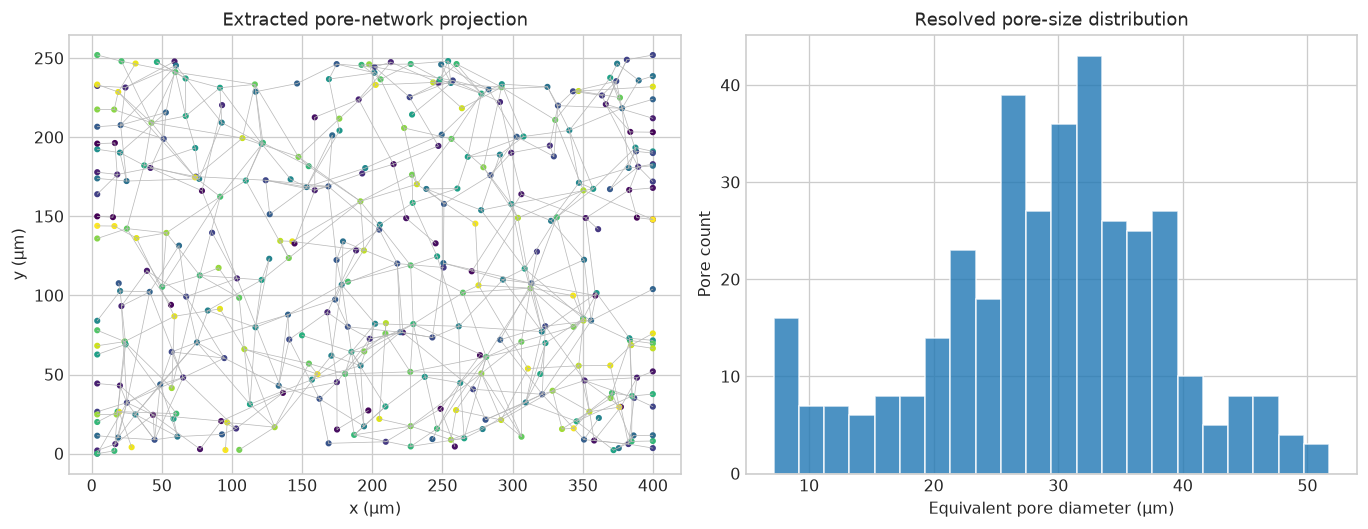

,metric,value,unit
0,pores,368,count
1,throats,629,count
2,disconnected pores after cleanup,0,count
3,mean permeability,404.4,mD
4,fluid-to-fluid relative difference,4.694e-14,-


In [11]:
coordinates = pore_network["pore.coords"]
connections = pore_network["throat.conns"]
network_figure, network_axes = plt.subplots(1, 2, figsize=(12.0, 4.7))
for pore_a, pore_b in connections:
    network_axes[0].plot(
        coordinates[[pore_a, pore_b], 0] * 1.0e6,
        coordinates[[pore_a, pore_b], 1] * 1.0e6,
        color="0.72",
        linewidth=0.45,
    )
network_axes[0].scatter(
    coordinates[:, 0] * 1.0e6,
    coordinates[:, 1] * 1.0e6,
    s=8,
    c=coordinates[:, 2] * 1.0e6,
    cmap="viridis",
)
network_axes[0].set(
    xlabel="x (µm)",
    ylabel="y (µm)",
    title="Extracted pore-network projection",
)
network_axes[1].hist(
    pore_network["pore.diameter"] * 1.0e6,
    bins=22,
    color="tab:blue",
    alpha=0.8,
    edgecolor="white",
)
network_axes[1].set(
    xlabel="Equivalent pore diameter (µm)",
    ylabel="Pore count",
    title="Resolved pore-size distribution",
)
network_figure.tight_layout()
plt.show()

network_summary = pd.DataFrame(
    {
        "metric": [
            "pores",
            "throats",
            "disconnected pores after cleanup",
            "mean permeability",
            "fluid-to-fluid relative difference",
        ],
        "value": [
            pore_network.Np,
            pore_network.Nt,
            len(
                op.utils.check_network_health(pore_network)[
                    "disconnected_pores"
                ]
            ),
            core_permeability_md,
            abs(
                oil_network_permeability
                - water_network_permeability
            )
            / oil_network_permeability,
        ],
        "unit": ["count", "count", "count", "mD", "-"],
    }
)
display(network_summary)


## 5. SCAL: relative permeability, capillary pressure, and fractional flow

Absolute permeability does not say how oil and water share the pore space. A transparent
Corey model supplies relative permeability for the field-scale teaching case:

$$S_e=\frac{S_w-S_{wc}}{1-S_{wc}-S_{or}}$$

$$k_{rw}=k_{rw,e}S_e^{n_w}$$

$$k_{ro}=k_{ro,e}(1-S_e)^{n_o}$$

A Brooks-Corey drainage curve supplies the OPM handoff:

$$p_c=p_eS_e^{-1/\lambda}$$

Fractional water flow, neglecting gravity and capillary flux, is

$$f_w=\frac{k_{rw}/\mu_w}{k_{rw}/\mu_w+k_{ro}/\mu_o}$$

Endpoints and exponents are synthetic. A real model must preserve drainage/imbibition
history, hysteresis, wettability, saturation-height functions, and rock-type dependence.


In [12]:
SWC = 0.20
SOR = 0.20
KRW_ENDPOINT = 0.35
KRO_ENDPOINT = 0.90
WATER_COREY_EXPONENT = 3.0
OIL_COREY_EXPONENT = 2.0
BROOKS_COREY_LAMBDA = 2.2
ENTRY_PRESSURE_KPA = float(
    invasion_curve.loc[
        invasion_curve["nonwetting_saturation"] >= 0.02,
        "pc_kpa",
    ].iloc[0]
)


def saturation_functions(water_saturation):
    effective = np.clip(
        (water_saturation - SWC) / (1.0 - SWC - SOR),
        0.0,
        1.0,
    )
    krw = KRW_ENDPOINT * effective**WATER_COREY_EXPONENT
    kro = KRO_ENDPOINT * (1.0 - effective) ** OIL_COREY_EXPONENT
    pc_kpa = ENTRY_PRESSURE_KPA * np.maximum(
        effective,
        0.02,
    ) ** (-1.0 / BROOKS_COREY_LAMBDA)
    return effective, krw, kro, pc_kpa


water_saturation = np.linspace(SWC, 1.0 - SOR, 31)
effective_saturation, krw, kro, pc_kpa = saturation_functions(
    water_saturation
)
water_mobility = krw / water_viscosity_cp
oil_mobility = kro / oil_viscosity_cp
fractional_flow = water_mobility / (water_mobility + oil_mobility)
scal_table = pd.DataFrame(
    {
        "Sw": water_saturation,
        "krw": krw,
        "kro": kro,
        "Pc_bar": pc_kpa / 100.0,
        "fw": fractional_flow,
    }
)

dense_sw = np.linspace(SWC + 1.0e-4, 1.0 - SOR - 1.0e-4, 4000)
_, dense_krw, dense_kro, _ = saturation_functions(dense_sw)
dense_fw = (dense_krw / water_viscosity_cp) / (
    dense_krw / water_viscosity_cp + dense_kro / oil_viscosity_cp
)
fractional_flow_gradient = np.gradient(dense_fw, dense_sw)
tangent_gradient = dense_fw / (dense_sw - SWC)
shock_search = (dense_sw > SWC + 0.03) & (dense_sw < 1.0 - SOR - 0.03)
shock_index = np.flatnonzero(shock_search)[
    np.argmin(
        np.abs(
            fractional_flow_gradient[shock_search]
            - tangent_gradient[shock_search]
        )
    )
]
shock_saturation = dense_sw[shock_index]
shock_slope = tangent_gradient[shock_index]
homogeneous_breakthrough_pv = 1.0 / shock_slope

display(scal_table.iloc[::5].reset_index(drop=True))
print(f"Buckley-Leverett shock saturation: {shock_saturation:.3f}")
print(
    "Homogeneous one-dimensional breakthrough: "
    f"{homogeneous_breakthrough_pv:.3f} pore volume injected"
)


Buckley-Leverett shock saturation: 0.709
Homogeneous one-dimensional breakthrough: 0.548 pore volume injected


,Sw,krw,kro,Pc_bar,fw
0,0.2,0,0.9,0.1922,0
1,0.3,0.00162,0.625,0.07333,0.003307
2,0.4,0.01296,0.4,0.05351,0.03982
3,0.5,0.04375,0.225,0.0445,0.1992
4,0.6,0.1037,0.1,0.03905,0.5703
5,0.7,0.2025,0.025,0.03528,0.912
6,0.8,0.35,0,0.03248,1


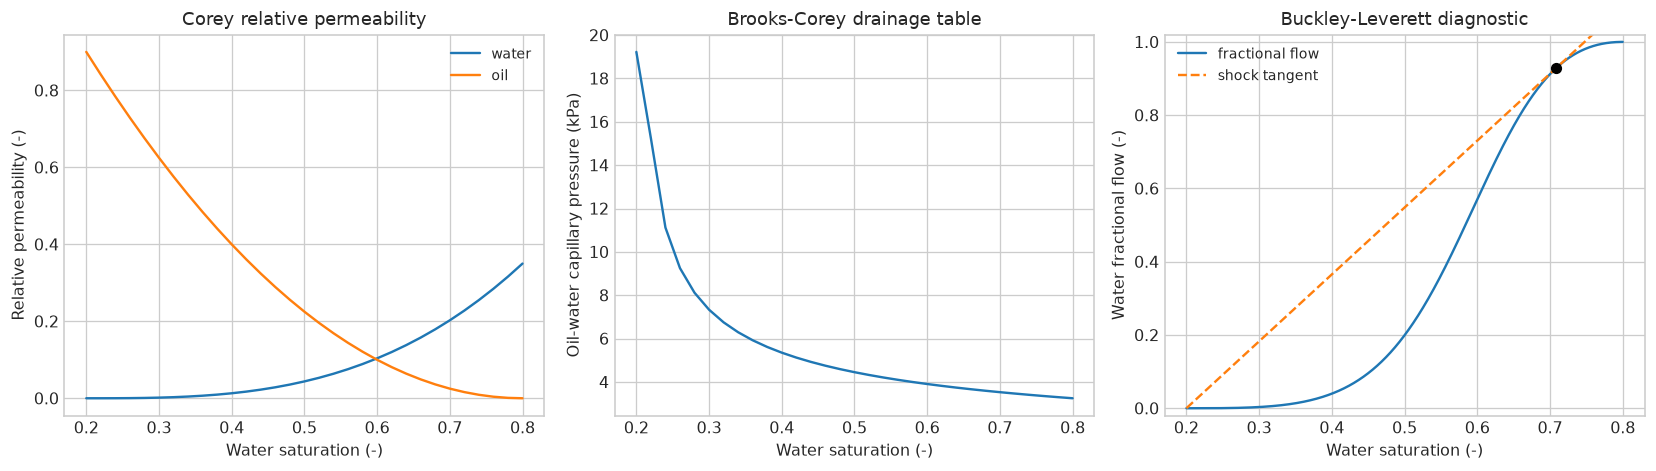

In [13]:
scal_figure, scal_axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
scal_axes[0].plot(water_saturation, krw, label="water")
scal_axes[0].plot(water_saturation, kro, label="oil")
scal_axes[0].set(
    xlabel="Water saturation (-)",
    ylabel="Relative permeability (-)",
    title="Corey relative permeability",
)
scal_axes[0].legend()
scal_axes[1].plot(water_saturation, pc_kpa)
scal_axes[1].set(
    xlabel="Water saturation (-)",
    ylabel="Oil-water capillary pressure (kPa)",
    title="Brooks-Corey drainage table",
)
scal_axes[2].plot(dense_sw, dense_fw, label="fractional flow")
shock_line = shock_slope * (dense_sw - SWC)
scal_axes[2].plot(
    dense_sw,
    shock_line,
    linestyle="--",
    label="shock tangent",
)
scal_axes[2].scatter(
    [shock_saturation],
    [dense_fw[shock_index]],
    color="black",
    zorder=3,
)
scal_axes[2].set(
    xlabel="Water saturation (-)",
    ylabel="Water fractional flow (-)",
    title="Buckley-Leverett diagnostic",
    ylim=(-0.02, 1.02),
)
scal_axes[2].legend()
scal_figure.tight_layout()
plt.show()


## 6. Upscaling to a heterogeneous reservoir grid

A core measurement is local. A reservoir model needs spatial correlation, anisotropy, and
barriers. GSTools generates a seeded anisotropic log-permeability field centred on the
pore-network result. A low-permeability north-south baffle with a short transmissive window
represents an unresolved fault or mud-rich streak.

Fine-to-coarse flow upscaling is directional: arithmetic averaging is appropriate for
layers parallel to flow, harmonic averaging for layers normal to flow, and neither is a
universal substitute for a boundary-condition-specific flow solve. The field below is
already the coarse teaching grid; no claim is made that its cells came directly from the
digital-rock sample.


,statistic,permeability_mD
0,minimum,13.84
1,P50,361.6
2,mean,529.4
3,maximum,"2,385"


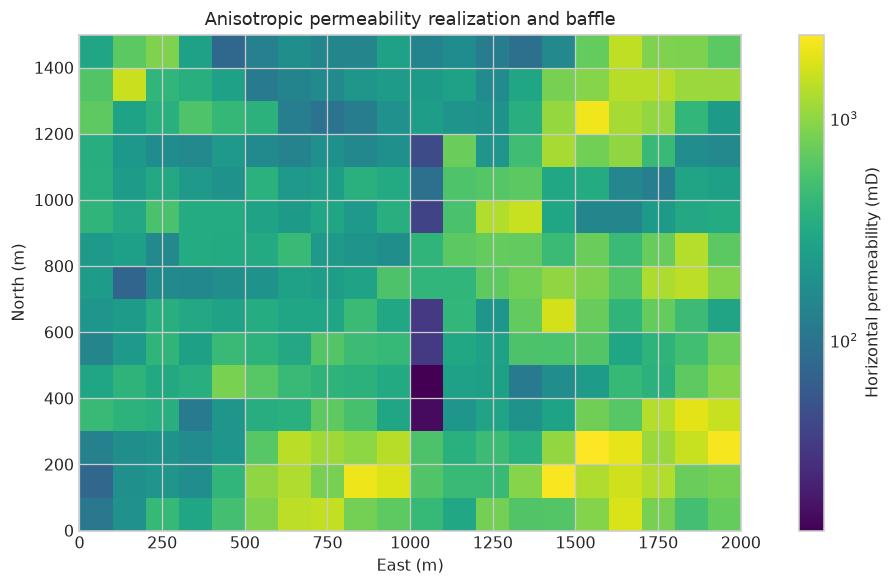

In [14]:
NX = 20
NY = 15
DX_M = 100.0
DY_M = 100.0
THICKNESS_M = 25.0
POROSITY = 0.22
x_centres_m = (np.arange(NX) + 0.5) * DX_M
y_centres_m = (np.arange(NY) + 0.5) * DY_M

covariance_model = gs.Exponential(
    dim=2,
    var=0.75**2,
    len_scale=[700.0, 250.0],
    angles=np.deg2rad(20.0),
)
spatial_random_field = gs.SRF(
    covariance_model,
    seed=20_260_806,
).structured((x_centres_m, y_centres_m))
standardized_field = (
    spatial_random_field - spatial_random_field.mean()
) / spatial_random_field.std()
permeability_md = core_permeability_md * np.exp(
    0.75 * standardized_field
)
permeability_md = np.clip(permeability_md, 25.0, 2500.0).T
permeability_md[3:12, 10] *= 0.08
permeability_md[7:9, 10] *= 12.5

grid_summary = pd.DataFrame(
    {
        "statistic": ["minimum", "P50", "mean", "maximum"],
        "permeability_mD": [
            permeability_md.min(),
            np.median(permeability_md),
            permeability_md.mean(),
            permeability_md.max(),
        ],
    }
)
display(grid_summary)

grid_figure, grid_axis = plt.subplots(figsize=(10.5, 5.2))
permeability_image = grid_axis.imshow(
    permeability_md,
    origin="lower",
    extent=[0.0, NX * DX_M, 0.0, NY * DY_M],
    norm=LogNorm(vmin=permeability_md.min(), vmax=permeability_md.max()),
    cmap="viridis",
    aspect="equal",
)
grid_figure.colorbar(
    permeability_image,
    ax=grid_axis,
    label="Horizontal permeability (mD)",
)
grid_axis.set(
    xlabel="East (m)",
    ylabel="North (m)",
    title="Anisotropic permeability realization and baffle",
)
grid_figure.tight_layout()
plt.show()


## 7. Well productivity and pressure communication

A Peaceman-style radial screening model connects rock and PVT to well count:

$$q_o=\frac{2\pi khk_{ro}\Delta p}{\mu_oB_o\left[\ln(r_e/r_w)+s\right]}$$

where $h$ is completed thickness, $B_o$ is oil formation-volume factor, $r_e$ is effective
grid radius, $r_w$ is wellbore radius, and $s$ is skin. The estimate is for a vertical well
in a homogeneous cell; deviated wells, fractures, non-Darcy flow, partial penetration, and
pressure-dependent PVT require a richer inflow model.

Pressure diffusivity illustrates why pressure usually communicates faster than saturation:

$$\alpha_p=\frac{k}{\phi\mu c_t}$$

with total compressibility $c_t$ in Pa⁻¹. Saturation transport is controlled by pore-volume
replacement and fractional flow rather than by this pressure diffusion time alone.


In [15]:
EFFECTIVE_GRID_RADIUS_M = 0.14 * math.sqrt(DX_M**2 + DY_M**2)
WELLBORE_RADIUS_M = 0.10
SKIN = 2.0
OIL_FORMATION_VOLUME_FACTOR = 1.25
DESIGN_DRAWDOWN_BAR = 70.0
TOTAL_COMPRESSIBILITY_PER_PA = 1.2e-9

representative_permeability_m2 = (
    np.median(permeability_md) * M2_PER_MD
)
oil_productivity_m3_s_pa = (
    2.0
    * np.pi
    * representative_permeability_m2
    * THICKNESS_M
    * KRO_ENDPOINT
    / (oil_viscosity_cp / 1000.0)
    / OIL_FORMATION_VOLUME_FACTOR
    / (math.log(EFFECTIVE_GRID_RADIUS_M / WELLBORE_RADIUS_M) + SKIN)
)
oil_productivity_m3_day_bar = (
    oil_productivity_m3_s_pa * STANDARD_SECONDS_PER_DAY * 1.0e5
)
single_well_potential_m3_day = (
    oil_productivity_m3_day_bar * DESIGN_DRAWDOWN_BAR
)
target_pattern_rate_m3_day = 2500.0
screened_producer_count = math.ceil(
    target_pattern_rate_m3_day / single_well_potential_m3_day
)
pressure_diffusivity_m2_s = (
    representative_permeability_m2
    / POROSITY
    / (oil_viscosity_cp / 1000.0)
    / TOTAL_COMPRESSIBILITY_PER_PA
)
communication_distance_m = 1500.0
pressure_communication_days = (
    communication_distance_m**2
    / (4.0 * pressure_diffusivity_m2_s)
    / STANDARD_SECONDS_PER_DAY
)

well_screen = pd.DataFrame(
    {
        "metric": [
            "oil productivity index",
            "single-well potential",
            "screened producer count",
            "pressure diffusivity",
            "1.5 km pressure-communication time",
        ],
        "value": [
            oil_productivity_m3_day_bar,
            single_well_potential_m3_day,
            screened_producer_count,
            pressure_diffusivity_m2_s,
            pressure_communication_days,
        ],
        "unit": [
            "m³/d/bar",
            "m³/d",
            "well",
            "m²/s",
            "day",
        ],
    }
)
display(well_screen)


,metric,value,unit
0,oil productivity index,115.8,m³/d/bar
1,single-well potential,"8,104",m³/d
2,screened producer count,1,well
3,pressure diffusivity,3.271,m²/s
4,1.5 km pressure-communication time,1.991,day


## 8. Transparent two-phase finite-volume waterflood

The pressure solve uses two-point flux approximation with harmonic face conductance. For a
connection between cells $i$ and $j$,

$$q_{ij}=T_{ij}(p_i-p_j)$$

$$T_{ij}=\frac{A_{ij}}{d_{ij}}\operatorname{harmonic}\left(K_i\lambda_{t,i},K_j\lambda_{t,j}\right)$$

Water transport is explicit and upwind:

$$\phi V\frac{S_w^{n+1}-S_w^n}{\Delta t}=q_w-\sum_j f_{w,up}q_{ij}$$

The time step adapts to limit the largest saturation change. The injector and producer are
represented by three completed cells each. Total reservoir volume rate is fixed and the
middle producer completion fixes the pressure datum at 150 bara. This IMPES teaching model
is incompressible, horizontal, isothermal, two-phase, and capillary-free; OPM Flow is the
intended next step when those assumptions are inadequate.


In [16]:
CELL_COUNT = NX * NY
cell_pore_volume_m3 = np.full(
    CELL_COUNT,
    DX_M * DY_M * THICKNESS_M * POROSITY,
)
permeability_m2_flat = permeability_md.ravel() * M2_PER_MD

connection_rows = []
for row_index in range(NY):
    for column_index in range(NX):
        cell_index = row_index * NX + column_index
        if column_index + 1 < NX:
            connection_rows.append(
                (
                    cell_index,
                    cell_index + 1,
                    THICKNESS_M * DY_M / DX_M,
                )
            )
        if row_index + 1 < NY:
            connection_rows.append(
                (
                    cell_index,
                    cell_index + NX,
                    THICKNESS_M * DX_M / DY_M,
                )
            )
connection_array = np.asarray(connection_rows, dtype=float)
connection_i = connection_array[:, 0].astype(int)
connection_j = connection_array[:, 1].astype(int)
connection_geometry = connection_array[:, 2]

injector_cells = np.asarray(
    [row_index * NX + 1 for row_index in [6, 7, 8]],
    dtype=int,
)
producer_cells = np.asarray(
    [row_index * NX + NX - 2 for row_index in [6, 7, 8]],
    dtype=int,
)
pressure_reference_cell = int(producer_cells[1])


def solve_pressure_and_flux(water_saturation, rate_m3_day):
    effective, krw_local, kro_local, _ = saturation_functions(
        water_saturation
    )
    del effective
    water_mobility_si = krw_local / (water_viscosity_cp / 1000.0)
    oil_mobility_si = kro_local / (oil_viscosity_cp / 1000.0)
    total_mobility_si = water_mobility_si + oil_mobility_si
    fractional_water = water_mobility_si / total_mobility_si

    cell_conductance = permeability_m2_flat * total_mobility_si
    face_conductance = (
        2.0
        * cell_conductance[connection_i]
        * cell_conductance[connection_j]
        / np.maximum(
            cell_conductance[connection_i]
            + cell_conductance[connection_j],
            1.0e-30,
        )
        * connection_geometry
    )

    rate_m3_s = rate_m3_day / STANDARD_SECONDS_PER_DAY
    well_rates_m3_s = np.zeros(CELL_COUNT)
    well_rates_m3_s[injector_cells] = (
        rate_m3_s / len(injector_cells)
    )
    well_rates_m3_s[producer_cells] = (
        -rate_m3_s / len(producer_cells)
    )

    pressure_matrix = lil_matrix((CELL_COUNT, CELL_COUNT))
    for cell_i, cell_j, transmissibility in zip(
        connection_i,
        connection_j,
        face_conductance,
    ):
        pressure_matrix[cell_i, cell_i] += transmissibility
        pressure_matrix[cell_j, cell_j] += transmissibility
        pressure_matrix[cell_i, cell_j] -= transmissibility
        pressure_matrix[cell_j, cell_i] -= transmissibility

    right_hand_side = well_rates_m3_s.copy()
    pressure_matrix.rows[pressure_reference_cell] = [
        pressure_reference_cell
    ]
    pressure_matrix.data[pressure_reference_cell] = [1.0]
    right_hand_side[pressure_reference_cell] = (
        PRODUCER_BHP_BARA * 1.0e5
    )
    pressure_pa = spsolve(
        pressure_matrix.tocsr(),
        right_hand_side,
    )
    total_face_rate_m3_s = face_conductance * (
        pressure_pa[connection_i] - pressure_pa[connection_j]
    )
    upwind_cells = np.where(
        total_face_rate_m3_s >= 0.0,
        connection_i,
        connection_j,
    )
    water_face_rate_m3_s = (
        total_face_rate_m3_s * fractional_water[upwind_cells]
    )
    return {
        "pressure_pa": pressure_pa,
        "fractional_water": fractional_water,
        "well_rates_m3_s": well_rates_m3_s,
        "water_face_rate_m3_s": water_face_rate_m3_s,
    }


def simulate_waterflood(
    name,
    rate_m3_day,
    years=8.0,
    maximum_saturation_change=0.018,
):
    water_saturation = np.full(CELL_COUNT, SWC)
    initial_water_volume_m3 = np.sum(
        water_saturation * cell_pore_volume_m3
    )
    initial_oil_volume_m3 = np.sum(
        (1.0 - water_saturation) * cell_pore_volume_m3
    )
    end_time_s = years * 365.25 * STANDARD_SECONDS_PER_DAY
    elapsed_time_s = 0.0
    cumulative_water_injected_m3 = 0.0
    cumulative_water_produced_m3 = 0.0
    cumulative_oil_produced_m3 = 0.0
    breakthrough_time_year = np.nan
    history_rows = []
    snapshots = {}
    snapshot_years = [1.0, 4.0, 7.0, years]
    step_count = 0
    maximum_balance_residual = 0.0

    while elapsed_time_s < end_time_s - 1.0:
        state = solve_pressure_and_flux(
            water_saturation,
            rate_m3_day,
        )
        water_volume_rate_m3_s = np.zeros(CELL_COUNT)
        np.add.at(
            water_volume_rate_m3_s,
            connection_i,
            -state["water_face_rate_m3_s"],
        )
        np.add.at(
            water_volume_rate_m3_s,
            connection_j,
            state["water_face_rate_m3_s"],
        )
        well_water_rate_m3_s = np.where(
            state["well_rates_m3_s"] > 0.0,
            state["well_rates_m3_s"],
            state["well_rates_m3_s"]
            * state["fractional_water"],
        )
        water_volume_rate_m3_s += well_water_rate_m3_s
        saturation_rate_s = (
            water_volume_rate_m3_s / cell_pore_volume_m3
        )
        largest_rate_s = np.max(np.abs(saturation_rate_s))
        time_step_s = min(
            10.0 * STANDARD_SECONDS_PER_DAY,
            maximum_saturation_change
            / max(largest_rate_s, 1.0e-30),
            end_time_s - elapsed_time_s,
        )
        next_saturation = (
            water_saturation + saturation_rate_s * time_step_s
        )
        if (
            next_saturation.min() < SWC - 1.0e-8
            or next_saturation.max() > 1.0 - SOR + 1.0e-8
        ):
            raise RuntimeError("Explicit saturation update left SCAL bounds.")

        injection_rate_m3_s = rate_m3_day / STANDARD_SECONDS_PER_DAY
        water_production_rate_m3_s = -np.sum(
            well_water_rate_m3_s[producer_cells]
        )
        oil_production_rate_m3_s = (
            injection_rate_m3_s - water_production_rate_m3_s
        )
        cumulative_water_injected_m3 += (
            injection_rate_m3_s * time_step_s
        )
        cumulative_water_produced_m3 += (
            water_production_rate_m3_s * time_step_s
        )
        cumulative_oil_produced_m3 += (
            oil_production_rate_m3_s * time_step_s
        )
        elapsed_time_s += time_step_s
        water_saturation = next_saturation
        step_count += 1

        water_cut = water_production_rate_m3_s / injection_rate_m3_s
        if np.isnan(breakthrough_time_year) and water_cut >= 0.05:
            breakthrough_time_year = (
                elapsed_time_s
                / STANDARD_SECONDS_PER_DAY
                / 365.25
            )
        water_inventory_m3 = np.sum(
            water_saturation * cell_pore_volume_m3
        )
        balance_residual = (
            water_inventory_m3
            - initial_water_volume_m3
            - cumulative_water_injected_m3
            + cumulative_water_produced_m3
        )
        relative_balance_residual = abs(balance_residual) / max(
            cumulative_water_injected_m3,
            1.0,
        )
        maximum_balance_residual = max(
            maximum_balance_residual,
            relative_balance_residual,
        )

        if (
            not history_rows
            or elapsed_time_s - history_rows[-1]["time_s"]
            >= 30.0 * STANDARD_SECONDS_PER_DAY
            or elapsed_time_s >= end_time_s - 1.0
        ):
            history_rows.append(
                {
                    "time_s": elapsed_time_s,
                    "time_year": (
                        elapsed_time_s
                        / STANDARD_SECONDS_PER_DAY
                        / 365.25
                    ),
                    "oil_rate_m3_day": (
                        oil_production_rate_m3_s
                        * STANDARD_SECONDS_PER_DAY
                    ),
                    "water_rate_m3_day": (
                        water_production_rate_m3_s
                        * STANDARD_SECONDS_PER_DAY
                    ),
                    "water_cut": water_cut,
                    "cumulative_oil_m3": cumulative_oil_produced_m3,
                    "recovery_fraction": (
                        cumulative_oil_produced_m3
                        / initial_oil_volume_m3
                    ),
                    "pore_volume_injected": (
                        cumulative_water_injected_m3
                        / np.sum(cell_pore_volume_m3)
                    ),
                    "mean_injector_pressure_bara": (
                        np.mean(
                            state["pressure_pa"][injector_cells]
                        )
                        / 1.0e5
                    ),
                    "relative_water_balance_residual": (
                        relative_balance_residual
                    ),
                }
            )
        for snapshot_year in snapshot_years:
            if (
                snapshot_year not in snapshots
                and elapsed_time_s
                >= snapshot_year
                * 365.25
                * STANDARD_SECONDS_PER_DAY
            ):
                snapshots[snapshot_year] = water_saturation.reshape(
                    NY,
                    NX,
                ).copy()

    final_state = solve_pressure_and_flux(
        water_saturation,
        rate_m3_day,
    )
    history = pd.DataFrame(history_rows)
    return {
        "name": name,
        "rate_m3_day": rate_m3_day,
        "history": history,
        "snapshots": snapshots,
        "final_saturation": water_saturation.reshape(NY, NX),
        "final_pressure_bara": (
            final_state["pressure_pa"].reshape(NY, NX) / 1.0e5
        ),
        "breakthrough_time_year": breakthrough_time_year,
        "maximum_balance_residual": maximum_balance_residual,
        "step_count": step_count,
    }


In [17]:
base_case = simulate_waterflood(
    "base",
    rate_m3_day=2500.0,
)
accelerated_case = simulate_waterflood(
    "accelerated",
    rate_m3_day=4000.0,
)
refined_time_step_case = simulate_waterflood(
    "base refined time step",
    rate_m3_day=2500.0,
    maximum_saturation_change=0.009,
)


def case_summary(case):
    final = case["history"].iloc[-1]
    return {
        "case": case["name"],
        "rate_m3_day": case["rate_m3_day"],
        "steps": case["step_count"],
        "breakthrough_year_at_5pct_wc": case[
            "breakthrough_time_year"
        ],
        "final_water_cut": final["water_cut"],
        "final_recovery_fraction": final["recovery_fraction"],
        "final_pore_volume_injected": final["pore_volume_injected"],
        "maximum_injector_pressure_bara": case["history"][
            "mean_injector_pressure_bara"
        ].max(),
        "maximum_water_balance_residual": case[
            "maximum_balance_residual"
        ],
    }


case_summary_table = pd.DataFrame(
    [
        case_summary(base_case),
        case_summary(accelerated_case),
        case_summary(refined_time_step_case),
    ]
)
display(case_summary_table)


,case,rate_m3_day,steps,breakthrough_year_at_5pct_wc,final_water_cut,final_recovery_fraction,final_pore_volume_injected,maximum_injector_pressure_bara,maximum_water_balance_residual
0,base,"2,500",493,7.499,0.1815,0.5493,0.4427,216,4.042e-14
1,accelerated,"4,000",644,4.687,0.875,0.6616,0.7084,258.5,4.042e-14
2,base refined time step,"2,500",969,7.489,0.1815,0.5492,0.4427,216.1,1.141e-13


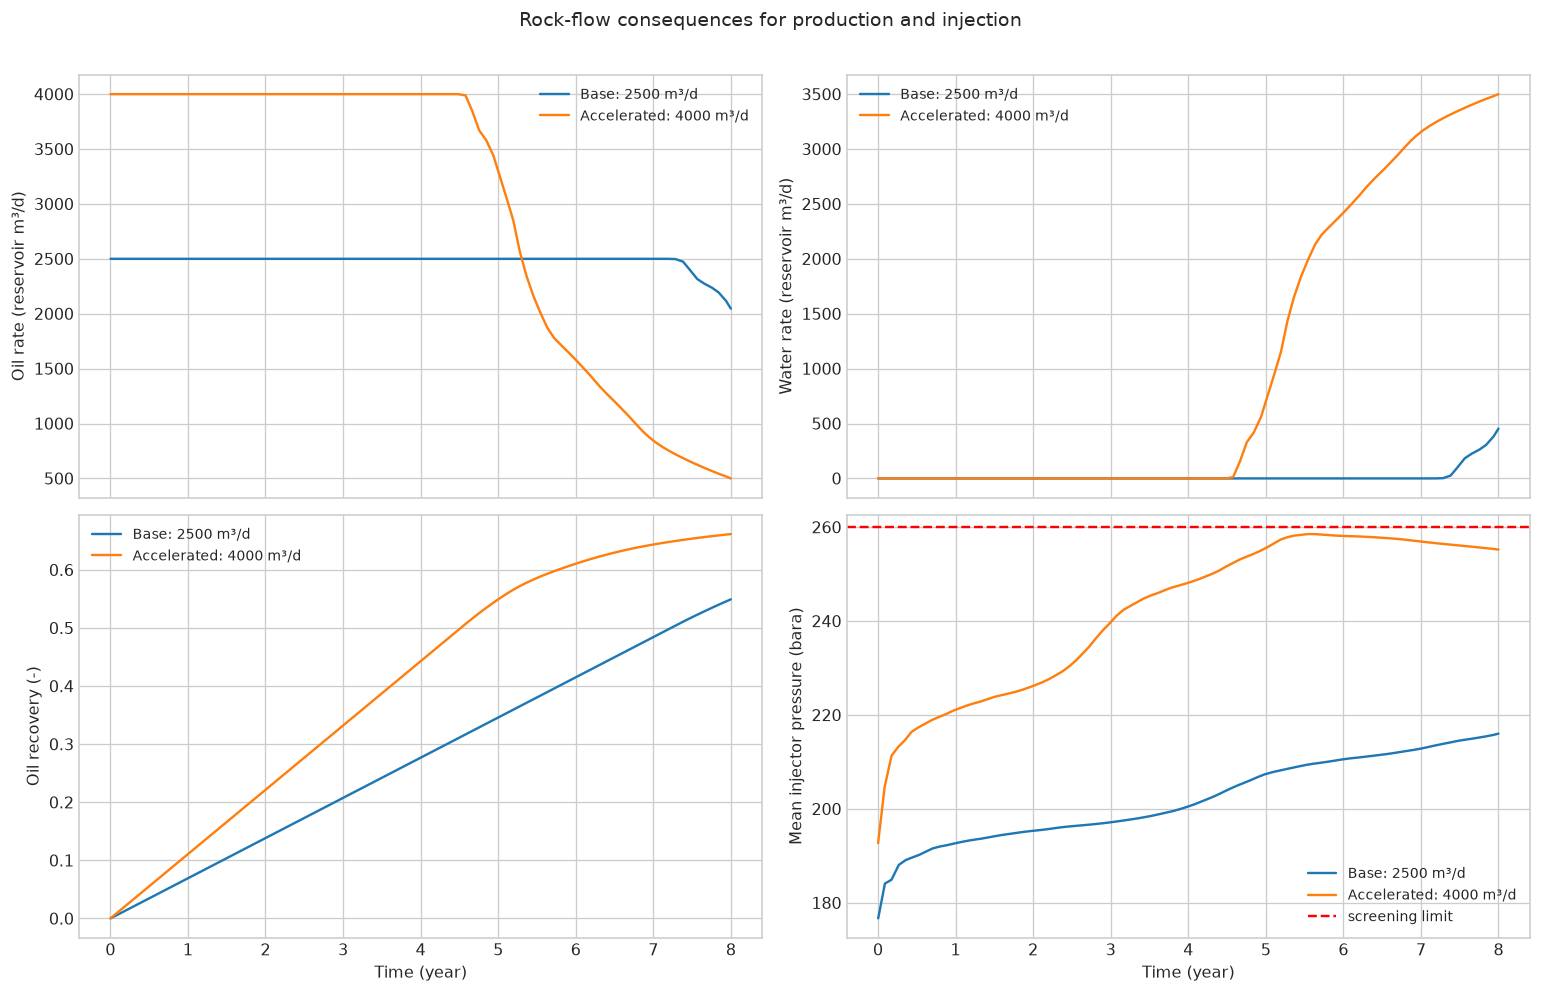

In [18]:
forecast_figure, forecast_axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 8.5),
    sharex=True,
)
case_styles = [
    (base_case, "Base: 2500 m³/d", "tab:blue"),
    (accelerated_case, "Accelerated: 4000 m³/d", "tab:orange"),
]
for case, label, color in case_styles:
    history = case["history"]
    forecast_axes[0, 0].plot(
        history["time_year"],
        history["oil_rate_m3_day"],
        label=label,
        color=color,
    )
    forecast_axes[0, 1].plot(
        history["time_year"],
        history["water_rate_m3_day"],
        label=label,
        color=color,
    )
    forecast_axes[1, 0].plot(
        history["time_year"],
        history["recovery_fraction"],
        label=label,
        color=color,
    )
    forecast_axes[1, 1].plot(
        history["time_year"],
        history["mean_injector_pressure_bara"],
        label=label,
        color=color,
    )
forecast_axes[1, 1].axhline(
    WATER_INJECTION_PRESSURE_LIMIT_BARA,
    linestyle="--",
    color="red",
    label="screening limit",
)
forecast_axes[0, 0].set_ylabel("Oil rate (reservoir m³/d)")
forecast_axes[0, 1].set_ylabel("Water rate (reservoir m³/d)")
forecast_axes[1, 0].set_ylabel("Oil recovery (-)")
forecast_axes[1, 1].set_ylabel("Mean injector pressure (bara)")
for axis in forecast_axes[1, :]:
    axis.set_xlabel("Time (year)")
for axis in forecast_axes.ravel():
    axis.legend()
forecast_figure.suptitle(
    "Rock-flow consequences for production and injection",
    y=1.01,
)
forecast_figure.tight_layout()
plt.show()


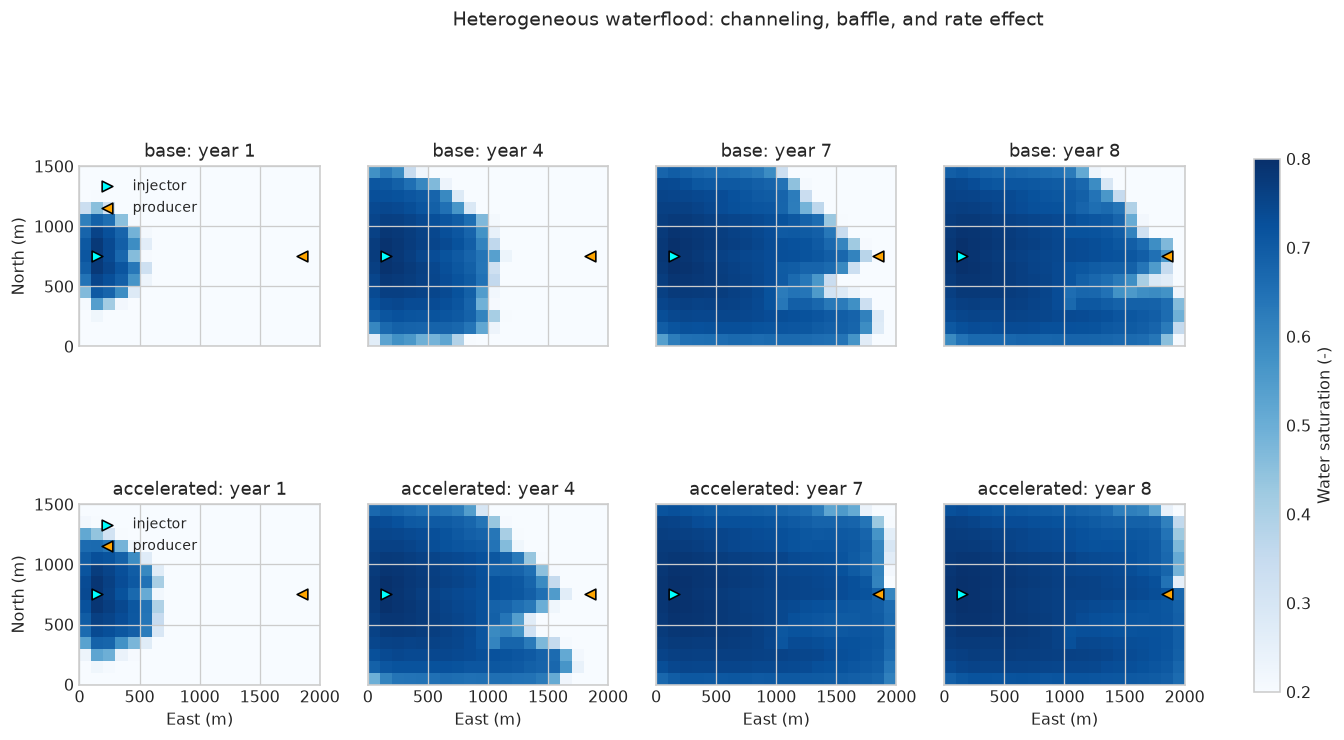

In [19]:
saturation_figure, saturation_axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 7.0),
    sharex=True,
    sharey=True,
)
for case_index, case in enumerate([base_case, accelerated_case]):
    snapshot_years = sorted(case["snapshots"])
    for column_index, snapshot_year in enumerate(snapshot_years):
        axis = saturation_axes[case_index, column_index]
        saturation_image = axis.imshow(
            case["snapshots"][snapshot_year],
            origin="lower",
            extent=[0.0, NX * DX_M, 0.0, NY * DY_M],
            cmap="Blues",
            vmin=SWC,
            vmax=1.0 - SOR,
            aspect="equal",
        )
        axis.scatter(
            x_centres_m[1],
            y_centres_m[7],
            marker=">",
            s=45,
            color="cyan",
            edgecolor="black",
            label="injector" if column_index == 0 else None,
        )
        axis.scatter(
            x_centres_m[NX - 2],
            y_centres_m[7],
            marker="<",
            s=45,
            color="orange",
            edgecolor="black",
            label="producer" if column_index == 0 else None,
        )
        axis.set_title(f"{case['name']}: year {snapshot_year:g}")
        if column_index == 0:
            axis.set_ylabel("North (m)")
            axis.legend(loc="upper left")
        if case_index == 1:
            axis.set_xlabel("East (m)")
saturation_figure.colorbar(
    saturation_image,
    ax=saturation_axes.ravel().tolist(),
    label="Water saturation (-)",
    shrink=0.86,
)
saturation_figure.suptitle(
    "Heterogeneous waterflood: channeling, baffle, and rate effect",
    y=1.01,
)
plt.show()


## 9. Field-development interpretation

The accelerated case injects and produces more pore volume, but it also advances
breakthrough and raises required injection pressure. A development choice therefore cannot
be based on recovery alone. At minimum, compare:

- reservoir pressure and fracture/injection limits;
- producer and injector count, completion length, skin, and uptime;
- oil acceleration versus water breakthrough and water-handling demand;
- displacement efficiency versus areal/vertical sweep and geological uncertainty;
- subsea and topside pressure losses, separator capacity, produced-water treatment,
  compression, power, and export constraints; and
- discounted value, emissions, and the option value of later infill or debottlenecking.

The next calculation converts reservoir oil and water rates to receiving-facility mass loads
and lets NeqSim flash the hydrocarbon stream at a 20 bara, 40 °C inlet separator while the
produced-water load is conserved separately.


In [20]:
constraint_rows = []
WATER_CAPACITY_M3_DAY = 1200.0
for case in [base_case, accelerated_case]:
    history = case["history"]
    final = history.iloc[-1]
    constraint_rows.append(
        {
            "case": case["name"],
            "injection_pressure_limit_bara": (
                WATER_INJECTION_PRESSURE_LIMIT_BARA
            ),
            "maximum_injector_pressure_bara": history[
                "mean_injector_pressure_bara"
            ].max(),
            "injection_pressure_margin_bar": (
                WATER_INJECTION_PRESSURE_LIMIT_BARA
                - history["mean_injector_pressure_bara"].max()
            ),
            "water_capacity_m3_day": WATER_CAPACITY_M3_DAY,
            "maximum_water_rate_m3_day": history[
                "water_rate_m3_day"
            ].max(),
            "water_capacity_margin_m3_day": (
                WATER_CAPACITY_M3_DAY
                - history["water_rate_m3_day"].max()
            ),
        }
    )
constraint_table = pd.DataFrame(constraint_rows)
constraint_table["hard_limit_exceeded"] = (
    constraint_table["injection_pressure_margin_bar"] < 0.0
) | (constraint_table["water_capacity_margin_m3_day"] < 0.0)
display(constraint_table)


,case,injection_pressure_limit_bara,maximum_injector_pressure_bara,injection_pressure_margin_bar,water_capacity_m3_day,maximum_water_rate_m3_day,water_capacity_margin_m3_day,hard_limit_exceeded
0,base,260,216,43.97,"1,200",453.7,746.3,False
1,accelerated,260,258.5,1.478,"1,200","3,500","-2,300",True


## 10. NeqSim hydrocarbon separator and produced-water handoff

The reservoir model reports actual oil and water volumes. These are converted to mass with
NeqSim reservoir densities. The characterized hydrocarbon is flashed in a composable NeqSim
`Stream` and `ThreePhaseSeparator` at 20 bara and 40 °C. Produced water is retained as a
separate mass and volume load for the water-treatment train.

A combined high-water-cut CPA flash is intentionally not used. During notebook validation,
gas disappeared at intermediate water fractions and reappeared at higher water fraction.
The public reproducer and acceptance criteria are tracked in
[NeqSim issue #2856](https://github.com/equinor/neqsim/issues/2856). Separating the
hydrocarbon flash from the water-load ledger keeps the field-development results independent
of that open limitation.

This is a single-stage receiving-facility screen. A full development model would reconstruct
component rates from reservoir PVT, include wellbore and flowline pressure/temperature
history, and connect separation, compression, treatment, water handling, export, and flare
systems in a `ProcessSystem` or `ProcessModel`.


In [21]:
def run_separator_snapshot(case_name, time_year, oil_rate, water_rate):
    oil_mass_kg_s = (
        oil_rate * oil_density_kg_m3 / STANDARD_SECONDS_PER_DAY
    )
    water_mass_kg_s = (
        water_rate * water_density_kg_m3 / STANDARD_SECONDS_PER_DAY
    )
    received_mass_kg_s = oil_mass_kg_s + water_mass_kg_s
    feed_fluid = build_live_oil(40.0, 20.0)
    feed = Stream(f"{case_name} feed {time_year:.2f}", feed_fluid)
    feed.setFlowRate(float(oil_mass_kg_s), "kg/sec")
    separator = ThreePhaseSeparator(
        f"{case_name} separator {time_year:.2f}",
        feed,
    )
    process = ProcessSystem()
    process.add(feed)
    process.add(separator)
    process.run()
    product_streams = [
        separator.getGasOutStream(),
        separator.getOilOutStream(),
        separator.getWaterOutStream(),
    ]
    hydrocarbon_product_mass_kg_s = sum(
        stream.getFlowRate("kg/sec")
        for stream in product_streams
    )
    return {
        "case": case_name,
        "time_year": time_year,
        "reservoir_oil_rate_m3_day": oil_rate,
        "reservoir_water_rate_m3_day": water_rate,
        "received_mass_kg_s": received_mass_kg_s,
        "hydrocarbon_feed_mass_kg_s": oil_mass_kg_s,
        "produced_water_load_kg_s": water_mass_kg_s,
        "separator_gas_Sm3_day": product_streams[0].getFlowRate(
            "Sm3/day"
        ),
        "separator_oil_kg_s": product_streams[1].getFlowRate(
            "kg/sec"
        ),
        "relative_hydrocarbon_mass_residual": abs(
            oil_mass_kg_s - hydrocarbon_product_mass_kg_s
        )
        / oil_mass_kg_s,
    }


separator_rows = []
for case in [base_case, accelerated_case]:
    history = case["history"]
    target_times = [1.0, 6.0, 8.0]
    for target_time in target_times:
        row_index = (
            history["time_year"] - target_time
        ).abs().idxmin()
        forecast_row = history.loc[row_index]
        separator_rows.append(
            run_separator_snapshot(
                case["name"],
                float(forecast_row["time_year"]),
                float(forecast_row["oil_rate_m3_day"]),
                float(forecast_row["water_rate_m3_day"]),
            )
        )

separator_table = pd.DataFrame(separator_rows)
display(separator_table)


,case,time_year,reservoir_oil_rate_m3_day,reservoir_water_rate_m3_day,received_mass_kg_s,hydrocarbon_feed_mass_kg_s,produced_water_load_kg_s,separator_gas_Sm3_day,separator_oil_kg_s,relative_hydrocarbon_mass_residual
0,base,0.9787,"2,500",-0,20.66,20.66,-0,8.575e+04,19.85,9.616e-13
1,base,5.992,"2,500",-0,20.66,20.66,-0,8.575e+04,19.85,9.616e-13
2,base,8,"2,046",453.7,22.08,16.91,5.168,7.018e+04,16.25,1.47e-15
3,accelerated,0.9673,"4,000",-0,33.06,33.06,-0,1.372e+05,31.76,9.619e-13
4,accelerated,6.002,"1,579","2,421",40.63,13.05,27.58,5.416e+04,12.54,1.361e-15
5,accelerated,8,499.9,"3,500",44,4.132,39.87,1.715e+04,3.969,9.614e-13


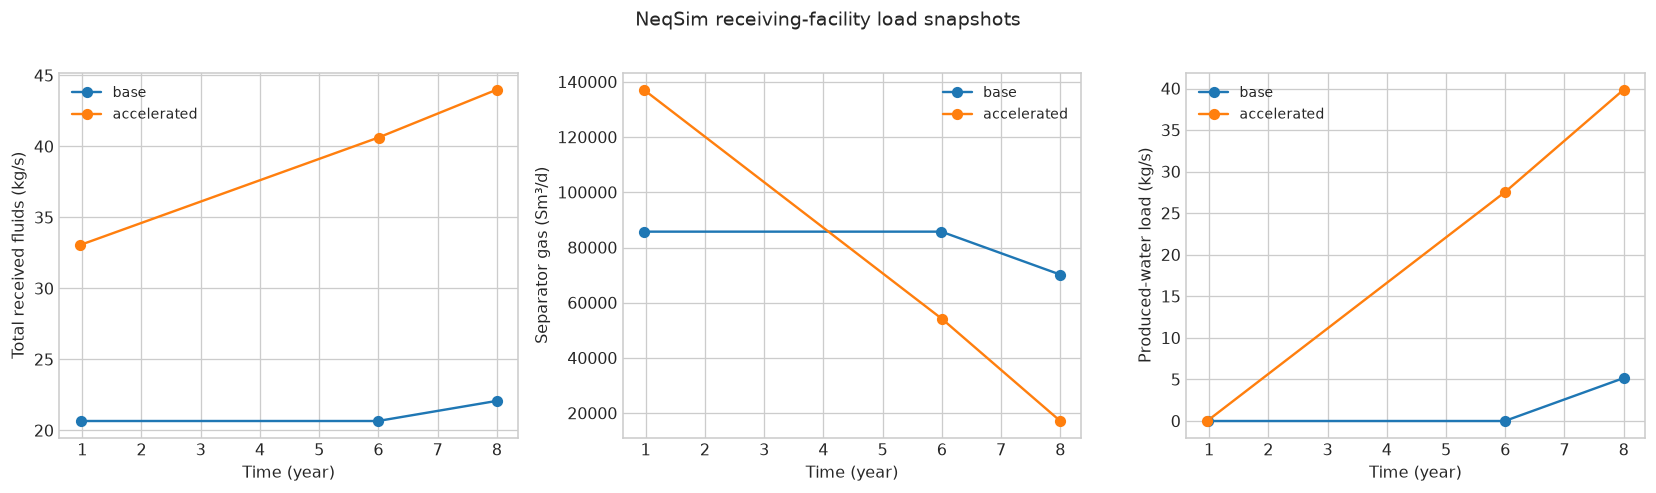

In [22]:
facility_figure, facility_axes = plt.subplots(
    1,
    3,
    figsize=(14.5, 4.2),
)
for case_name, color in [("base", "tab:blue"), ("accelerated", "tab:orange")]:
    case_rows = separator_table[separator_table["case"] == case_name]
    facility_axes[0].plot(
        case_rows["time_year"],
        case_rows["received_mass_kg_s"],
        marker="o",
        label=case_name,
        color=color,
    )
    facility_axes[1].plot(
        case_rows["time_year"],
        case_rows["separator_gas_Sm3_day"],
        marker="o",
        label=case_name,
        color=color,
    )
    facility_axes[2].plot(
        case_rows["time_year"],
        case_rows["produced_water_load_kg_s"],
        marker="o",
        label=case_name,
        color=color,
    )
facility_axes[0].set_ylabel("Total received fluids (kg/s)")
facility_axes[1].set_ylabel("Separator gas (Sm³/d)")
facility_axes[2].set_ylabel("Produced-water load (kg/s)")
for axis in facility_axes:
    axis.set_xlabel("Time (year)")
    axis.legend()
facility_figure.suptitle(
    "NeqSim receiving-facility load snapshots",
    y=1.01,
)
facility_figure.tight_layout()
plt.show()


## 11. Export to an OPM Flow rock/PVT workflow

The arrays below are not a complete deck. They are explicit handoffs:

- `PERMX` and `PORO` describe the coarse rock realization;
- `SWOF` carries the synthetic saturation functions and capillary pressure;
- NeqSim-generated PVT should be written as `PVTO`, `PVDG`, and `PVTW`; and
- wells, controls, faults, aquifers, equilibration, and schedule belong in a complete deck.

Continue with [NeqSim black-oil tables and OPM Flow](neqsim_opm_flow_blackoil_coupling.ipynb)
or the broader [subsurface-to-forecast workflow](subsurface_data_to_opm_flow_production_forecast.ipynb).


In [23]:
def eclipse_keyword(keyword, values, values_per_line=8):
    flattened = np.asarray(values).ravel()
    lines = [keyword]
    for start in range(0, len(flattened), values_per_line):
        chunk = flattened[start : start + values_per_line]
        lines.append(" ".join(f"{value:.7g}" for value in chunk))
    lines.append("/")
    return "\n".join(lines)


swof_lines = ["SWOF"]
for row in scal_table.itertuples(index=False):
    swof_lines.append(
        f" {row.Sw:.6f} {row.krw:.7f} {row.kro:.7f} {row.Pc_bar:.7f}"
    )
swof_lines.append("/")
rock_include = "\n\n".join(
    [
        eclipse_keyword("PORO", np.full_like(permeability_md, POROSITY)),
        eclipse_keyword("PERMX", permeability_md),
        "\n".join(swof_lines),
    ]
)
rock_include_path = OUTPUT_DIRECTORY / "ROCK_FLOW_PROPERTIES.INC"
rock_include_path.write_text(rock_include + "\n", encoding="utf-8")
scal_table.to_csv(
    OUTPUT_DIRECTORY / "rock_flow_scal_table.csv",
    index=False,
)
permeability_handoff = pd.DataFrame(
    permeability_md,
    index=[f"J{index + 1}" for index in range(NY)],
    columns=[f"I{index + 1}" for index in range(NX)],
)
permeability_handoff.to_csv(
    OUTPUT_DIRECTORY / "rock_flow_permeability_md.csv"
)

print("Rock/SCAL include preview:")
print("\n".join(rock_include.splitlines()[:18]))
print(f"\nSaved: {rock_include_path}")


Rock/SCAL include preview:
PORO
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22
0.22 0.22 0.22 0.22 0.22 0.22 0.22 0.22

Saved: rock_flow_outputs/ROCK_FLOW_PROPERTIES.INC


## 12. Executable validation

The evidence ladder used here is:

1. **Analytical consistency:** Darcy permeability is independent of probe-fluid viscosity;
   Buckley-Leverett gives an independent homogeneous breakthrough scale.
2. **Conservation:** the finite-volume water balance and NeqSim separator mass balance close.
3. **Numerical sensitivity:** the base case is repeated with half the permitted saturation
   change per step.
4. **Physical trends:** higher rate raises injection pressure, injects more pore volume, and
   accelerates breakthrough.

These checks validate the implementation and qualitative engineering response. They do not
validate the synthetic geology or SCAL parameters against a field.


In [24]:
base_final = base_case["history"].iloc[-1]
accelerated_final = accelerated_case["history"].iloc[-1]
refined_final = refined_time_step_case["history"].iloc[-1]
time_step_recovery_difference = abs(
    base_final["recovery_fraction"]
    - refined_final["recovery_fraction"]
)
time_step_water_cut_difference = abs(
    base_final["water_cut"] - refined_final["water_cut"]
)
maximum_separator_mass_residual = separator_table[
    "relative_hydrocarbon_mass_residual"
].max()
permeability_relative_difference = abs(
    oil_network_permeability - water_network_permeability
) / oil_network_permeability

validation_checks = {
    "composition_is_single_oil_phase_at_initial_state": (
        reservoir_oil.getNumberOfPhases() == 1
        and reservoir_oil.hasPhaseType("oil")
    ),
    "connected_rock_reaches_outlet": outlet_voxels.sum() > 0,
    "pore_network_is_connected": (
        len(
            op.utils.check_network_health(pore_network)[
                "disconnected_pores"
            ]
        )
        == 0
    ),
    "absolute_permeability_is_fluid_invariant": (
        permeability_relative_difference < 1.0e-8
    ),
    "relative_permeability_is_bounded": (
        np.all((krw >= 0.0) & (krw <= 1.0))
        and np.all((kro >= 0.0) & (kro <= 1.0))
    ),
    "base_water_balance_closes": (
        base_case["maximum_balance_residual"] < 1.0e-10
    ),
    "accelerated_water_balance_closes": (
        accelerated_case["maximum_balance_residual"] < 1.0e-10
    ),
    "accelerated_rate_raises_injector_pressure": (
        accelerated_case["history"][
            "mean_injector_pressure_bara"
        ].max()
        > base_case["history"]["mean_injector_pressure_bara"].max()
    ),
    "accelerated_rate_breaks_through_no_later": (
        accelerated_case["breakthrough_time_year"]
        <= base_case["breakthrough_time_year"]
    ),
    "time_step_recovery_is_stable": (
        time_step_recovery_difference < 0.003
    ),
    "time_step_water_cut_is_stable": (
        time_step_water_cut_difference < 0.015
    ),
    "separator_mass_balance_closes": (
        maximum_separator_mass_residual < 1.0e-9
    ),
    "opm_handoff_exists": rock_include_path.is_file(),
}
validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)
if not all(validation_checks.values()):
    failed_checks = [
        name for name, passed in validation_checks.items() if not passed
    ]
    raise AssertionError(f"Validation failed: {failed_checks}")

numerical_sensitivity = pd.DataFrame(
    {
        "metric": [
            "final recovery absolute difference",
            "final water-cut absolute difference",
            "maximum separator mass residual",
            "permeability probe-fluid relative difference",
        ],
        "value": [
            time_step_recovery_difference,
            time_step_water_cut_difference,
            maximum_separator_mass_residual,
            permeability_relative_difference,
        ],
    }
)
display(numerical_sensitivity)
print(f"All {len(validation_checks)} validation checks passed.")


All 13 validation checks passed.


,check,passed
0,composition_is_single_oil_phase_at_initial_state,True
1,connected_rock_reaches_outlet,True
2,pore_network_is_connected,True
3,absolute_permeability_is_fluid_invariant,True
4,relative_permeability_is_bounded,True
5,base_water_balance_closes,True
6,accelerated_water_balance_closes,True
7,accelerated_rate_raises_injector_pressure,True
8,accelerated_rate_breaks_through_no_later,True
9,time_step_recovery_is_stable,True


,metric,value
0,final recovery absolute difference,9.216e-05
1,final water-cut absolute difference,2.002e-05
2,maximum separator mass residual,9.619e-13
3,permeability probe-fluid relative difference,4.694e-14


In [25]:
final_results = {
    "neqsim_commit": neqsim_commit,
    "neqsim_jar_sha256": neqsim_jar_sha256,
    "connected_porosity": float(connected_image.mean()),
    "pore_network_permeability_md": float(core_permeability_md),
    "oil_viscosity_cp_at_250_bara": oil_viscosity_cp,
    "water_viscosity_cp_at_250_bara": water_viscosity_cp,
    "buckley_leverett_breakthrough_pv": float(
        homogeneous_breakthrough_pv
    ),
    "base_breakthrough_year": float(
        base_case["breakthrough_time_year"]
    ),
    "accelerated_breakthrough_year": float(
        accelerated_case["breakthrough_time_year"]
    ),
    "base_final_recovery_fraction": float(
        base_final["recovery_fraction"]
    ),
    "accelerated_final_recovery_fraction": float(
        accelerated_final["recovery_fraction"]
    ),
    "base_max_injector_pressure_bara": float(
        base_case["history"]["mean_injector_pressure_bara"].max()
    ),
    "accelerated_max_injector_pressure_bara": float(
        accelerated_case["history"][
            "mean_injector_pressure_bara"
        ].max()
    ),
    "validation_checks_passed": int(sum(validation_checks.values())),
    "validation_checks_total": len(validation_checks),
    "neqsim_improvement_issue": 2856,
}
(OUTPUT_DIRECTORY / "final_results.json").write_text(
    json.dumps(final_results, indent=2) + "\n",
    encoding="utf-8",
)
print(json.dumps(final_results, indent=2))


{
  "neqsim_commit": "df68ad7295b9dae6a324d941761a303d9f301fb5",
  "neqsim_jar_sha256": "091465d928d7935a7197482b3b5aa41fecdd3535af7562893cc863c5026654fc",
  "connected_porosity": 0.24416097005208334,
  "pore_network_permeability_md": 404.3615729593747,
  "oil_viscosity_cp_at_250_bara": 0.41329432087860074,
  "water_viscosity_cp_at_250_bara": 0.3229778560693428,
  "buckley_leverett_breakthrough_pv": 0.5475376846271035,
  "base_breakthrough_year": 7.498676394725971,
  "accelerated_breakthrough_year": 4.686672746703733,
  "base_final_recovery_fraction": 0.5492596853735274,
  "accelerated_final_recovery_fraction": 0.6615794050227499,
  "base_max_injector_pressure_bara": 216.03154142732154,
  "accelerated_max_injector_pressure_bara": 258.5217186154662,
  "validation_checks_passed": 13,
  "validation_checks_total": 13,
  "neqsim_improvement_issue": 2856
}


## Results, limitations, and field-development use

The notebook has demonstrated a traceable chain from a voxelized pore space to reservoir and
facility decisions. The most important engineering lesson is that scale transitions require
explicit contracts: pore geometry informs core-scale functions; SCAL and upscaled rock
properties feed a grid model; reservoir rates and compositions feed wells and facilities;
and every transition carries uncertainty.

**Use in early field development**

- screen whether rate is more likely constrained by injectivity, producer productivity,
  sweep, produced water, or receiving-facility pressure and capacity;
- compare base and accelerated depletion/waterflood strategies before committing to well
  count and host upgrades;
- identify the laboratory and subsurface data that most affect the development decision;
- generate consistent rock, SCAL, PVT, rate, and facility-load handoffs for uncertainty
  realizations; and
- frame OPM Flow, ERT, NeqSim, and optimization studies without independently splicing
  incompatible P10/P50/P90 inputs.

**Important limitations**

- synthetic image, SCAL endpoints, spatial field, baffle, and wells;
- no geomechanics, stress-sensitive permeability, fractures, gravity segregation,
  compressible accumulation, capillary flux, gas flow, hysteresis, or compositional transport;
- explicit two-phase transport and fixed total well rates rather than fully implicit well
  controls;
- one horizontal layer and no vertical upscaling or saturation-height initialization; and
- one-stage hydrocarbon flash without wellbore/SURF hydraulics or a complete host process;
  the combined high-water-cut CPA limitation is tracked in
  [NeqSim #2856](https://github.com/equinor/neqsim/issues/2856).

## Suggested exercises

1. Fit Corey or LET parameters to laboratory drainage and imbibition data and add hysteresis.
2. Generate 50 conditioned GSTools realizations and rank complete development outcomes.
3. Add vertical layers, gravity, capillary flux, aquifer support, and pressure-dependent PVT.
4. Replace fixed-rate wells with BHP/rate switching and Peaceman well indices.
5. Export the rock and SCAL data to OPM Flow and compare breakthrough and mass balance.
6. Connect NeqSim well, flowline, separator, compressor, and produced-water constraints.
7. Optimize producer/injector placement, rate, and facility upgrades under uncertainty.

## References

- Blunt, M. J. (2017), *Multiphase Flow in Permeable Media*.
- Dake, L. P. (1978), *Fundamentals of Reservoir Engineering*.
- Aziz, K. and Settari, A. (1979), *Petroleum Reservoir Simulation*.
- Buckley, S. E. and Leverett, M. C. (1942), mechanism of fluid displacement in sands.
- [PoreSpy image-based two-phase flow examples](https://porespy.org/examples/simulations/tutorials/overview_of_two_phase_flow_part1.html)
- [OpenPNM permeability example](https://openpnm.org/examples/getting_started.html)
- [GSTools documentation](https://gstools.readthedocs.io/)
- [OPM Flow manual](https://opm-project.org/?page_id=955)
- [NeqSim source and documentation](https://github.com/equinor/neqsim)
